# 0_10 — Integrating the wider peptidase kinetics, and checking it against the narrow one

## Scope

`0_09_brenda_kinetics.ipynb` extracts BRENDA for the 40 EC numbers of the
serum panel. That scope came from the calibration specification, which is about
serum. The hypothesis under test in the `2_` notebooks is narrower in one sense
and wider in another: it asks whether a MEROPS matrix predicts the kinetics of
**its own** enzyme, which is a question about matrices, not about serum.

This notebook documents and validates the wider extraction: every peptidase EC
number BRENDA holds human kinetics for.

Two new artifacts are involved and both are audited here:

* `manifests/peptidase_ec_to_merops.tsv` — the EC to MEROPS mapping, built by
  `map_ec_to_merops.py`;
* `processed/kinetics/brenda_all_peptidases.parquet` — the extraction under
  that mapping, by `ingest_brenda.py --ec-mapping`.

## Why the mapping needs checking

The serum manifest was built in one direction: MEROPS code to UniProt to EC.
The wider mapping runs the opposite way: EC to reviewed human UniProt records to
their MEROPS cross-reference. The two therefore agree only if both are right,
which makes their overlap a genuine cross-check rather than a restatement.

## Questions

1. Do the two mappings agree on the EC numbers they share?
2. Does the wider extraction reproduce the narrow one, row for row, on the EC
   numbers both cover?
3. What does the wider scope add, and to which proteases?
4. Where one EC number maps to several MEROPS codes, what does that mean?

## Execution contract

**Inputs:** `data/serum_proteolysis_calibration/manifests/peptidase_ec_to_merops.tsv`; `data/serum_proteolysis_calibration/manifests/peptidase_ec_unresolved.json`; `data/serum_proteolysis_calibration/processed/kinetics/brenda_serum_proteases.parquet`; `data/serum_proteolysis_calibration/processed/kinetics/brenda_all_peptidases.parquet`; `data/merops/index.json`.

**Outputs:** `results/0_10_brenda_extension.csv`.

**Depends on:** none; it consumes acquisition products, not prior notebook outputs.

**Boundary:** More EC-to-MEROPS pairs do not mean more independent kinetic experiments.

In [1]:
import json
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    best_merops_dataset,
    merops_code_locations,
    parse_substrate,
    resolvable_subsites,
)

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
MAPPING_TABLE = common.SERUM_ROOT / "manifests" / "peptidase_ec_to_merops.tsv"
UNRESOLVED_REPORT = common.SERUM_ROOT / "manifests" / "peptidase_ec_unresolved.json"
MIN_FRET_LENGTH = 6

In [3]:
for path in (MAPPING_TABLE, UNRESOLVED_REPORT, common.BRENDA_KINETICS, common.BRENDA_ALL_PEPTIDASES):
    record = common.describe_source(path)
    print(f"{record['path']} | exists={record['exists']} | {record['bytes'] / 1e3:.0f} kB")

data/serum_proteolysis_calibration/manifests/peptidase_ec_to_merops.tsv | exists=True | 22 kB
data/serum_proteolysis_calibration/manifests/peptidase_ec_unresolved.json | exists=True | 2 kB
data/serum_proteolysis_calibration/processed/kinetics/brenda_serum_proteases.parquet | exists=True | 125 kB
data/serum_proteolysis_calibration/processed/kinetics/brenda_all_peptidases.parquet | exists=True | 268 kB


## The mapping and what it could not resolve

An EC number reaches the extraction only through a MEROPS code. The mapping
records which path produced each assignment, and an EC number that neither path
resolved is excluded and reported rather than guessed from name similarity.

In [4]:
mapping = pd.read_csv(MAPPING_TABLE, sep="\t", dtype=str).fillna("")
unresolved = json.loads(UNRESOLVED_REPORT.read_text())

from pep_compass.optimization.components.helpers.proteolysis import load_panel_metadata  # noqa: E402

names_preview = {
    entry["code"]: entry["name"]
    for entry in load_panel_metadata(list(range(36)), merops_root=common.MEROPS_ROOT)
}

print(f"EC numbers considered: {unresolved['n_candidate_ec']}")
print(f"  mapped:     {unresolved['n_mapped_ec']}")
print(f"  unresolved: {unresolved['n_unresolved_ec']}")
print()
print("mapping path used:")
print(mapping["mapping_source"].value_counts().to_string())
print()
print(f"distinct MEROPS codes reached: {mapping['merops_code'].nunique()}")
print()
print("EC numbers that could not be mapped, with the kinetics they carry:")
print(
    pd.DataFrame(unresolved["unresolved"])[
        ["ec_number", "recommended_name", "n_human_turnover_number", "n_human_km_value"]
    ].to_string(index=False)
)

EC numbers considered: 150
  mapped:     139
  unresolved: 11

mapping path used:
mapping_source
uniprot_human    215

distinct MEROPS codes reached: 204

EC numbers that could not be mapped, with the kinetics they carry:
 ec_number           recommended_name  n_human_turnover_number  n_human_km_value
 3.4.11.22           aminopeptidase I                        0                 2
  3.4.16.6         carboxypeptidase D                        0                 1
 3.4.17.11 glutamate carboxypeptidase                        2                 2
3.4.21.107               peptidase Do                        2                 2
3.4.21.119              kallikrein 13                        8                 8
 3.4.21.61                      Kexin                        0                 2
 3.4.22.26        cancer procoagulant                       10                10
 3.4.22.68             Ulp1 peptidase                        0                 1
  3.4.23.4                   chymosin            

## Cross-check against the serum manifest

The 40 EC numbers of the serum panel appear in both mappings, built in opposite
directions. Every disagreement on that overlap would be a defect in one of
them.

In [5]:
manifest = common.load_serum_manifest()
manifest_pairs = {
    (row["ec_number"].strip(), row["merops_code"].strip())
    for _, row in manifest.iterrows()
    if row["ec_number"].strip()
}
mapping_pairs = {
    (row["ec_number"].strip(), row["merops_code"].strip()) for _, row in mapping.iterrows()
}
shared_ec = {ec for ec, _ in manifest_pairs} & {ec for ec, _ in mapping_pairs}
manifest_on_shared = {pair for pair in manifest_pairs if pair[0] in shared_ec}
mapping_on_shared = {pair for pair in mapping_pairs if pair[0] in shared_ec}

print(f"EC numbers present in both mappings: {len(shared_ec)}")
print(f"  assignments agreeing:            {len(manifest_on_shared & mapping_on_shared)}")
print(f"  present only in the manifest:    {len(manifest_on_shared - mapping_on_shared)}")
print(f"  present only in the new mapping: {len(mapping_on_shared - manifest_on_shared)}")

extra = sorted(mapping_on_shared - manifest_on_shared)
if extra:
    print()
    print("additional MEROPS codes the reverse mapping attaches to a shared EC number:")
    for ec_number, code in extra:
        row = mapping.query("ec_number == @ec_number and merops_code == @code").iloc[0]
        print(f"  {ec_number} -> {code:9s} {row['protein_name'][:52]}")

assert not (manifest_on_shared - mapping_on_shared), (
    "the reverse mapping must reproduce every manifest assignment on the shared EC numbers"
)

EC numbers present in both mappings: 40
  assignments agreeing:            42
  present only in the manifest:    0
  present only in the new mapping: 4

additional MEROPS codes the reverse mapping attaches to a shared EC number:
  3.4.14.5 -> S09.007   Prolyl endopeptidase FAP
  3.4.14.5 -> S09.018   Dipeptidyl peptidase 8
  3.4.14.5 -> S09.019   Dipeptidyl peptidase 9
  3.4.24.11 -> M13.008   Membrane metallo-endopeptidase-like 1


### What an extra code on a shared EC number means

One EC number describes an activity, not a gene. Where several paralogues share
an activity, UniProt attaches the EC to each of them and the reverse mapping
returns all their MEROPS codes. Those are different enzymes with different
specificity matrices, so the extraction attaches the measurement to each of
them and the ambiguity is carried forward rather than resolved here.

The consequence for the `2_` notebooks is that a substrate measured for one EC
number can appear under more than one protease. Such a measurement is evidence
for whichever of them actually catalysed it, and treating it as evidence for all
of them inflates the count. The number of affected pairs is reported below.

In [6]:
codes_per_ec = mapping.groupby("ec_number")["merops_code"].nunique()
print(f"EC numbers mapping to exactly one MEROPS code: {int((codes_per_ec == 1).sum())}")
print(f"EC numbers mapping to several codes:          {int((codes_per_ec > 1).sum())}")
print()
print("the most ambiguous EC numbers:")
ambiguous = codes_per_ec.sort_values(ascending=False).head(8)
for ec_number, count in ambiguous.items():
    codes = sorted(mapping.query("ec_number == @ec_number")["merops_code"])
    name = mapping.query("ec_number == @ec_number")["brenda_recommended_name"].iloc[0]
    print(f"  {ec_number:12s} {count:2d} codes  {name[:34]:36s} {', '.join(codes[:6])}")

EC numbers mapping to exactly one MEROPS code: 114
EC numbers mapping to several codes:          25

the most ambiguous EC numbers:
  3.4.19.12    25 codes  ubiquitinyl hydrolase 1              C12.001, C12.003, C19.012, C19.013, C19.015, C19.020
  3.4.25.1      8 codes  proteasome endopeptidase complex     T01.010, T01.011, T01.012, T01.013, T01.014, T01.015
  3.4.21.4      5 codes  trypsin                              S01.085, S01.127, S01.174, S01.258, S01.298
  3.4.14.5      4 codes  dipeptidyl-peptidase IV              S09.003, S09.007, S09.018, S09.019
  3.4.11.18     4 codes  methionyl aminopeptidase             M01.022, M24.002, M24.017, M24.028
  3.4.19.13     4 codes  glutathione gamma-glutamate hydrol   T03.002, T03.006, T03.017, T03.024
  3.4.24.56     3 codes  insulysin                            M16.002, M16.982, M16.984
  3.4.17.22     3 codes  metallocarboxypeptidase D            M14.011, M14.016, M14.950


## Regression check on the extraction itself

Only the EC filter changed; the parser did not. The wider run must therefore
reproduce the narrow one exactly on the EC numbers both cover. A difference
would mean the extraction depends on the scope, which it must not.

In [7]:
narrow = pd.read_parquet(common.BRENDA_KINETICS)
wide = pd.read_parquet(common.BRENDA_ALL_PEPTIDASES)
shared_extraction = wide[wide["ec_number"].isin(narrow["ec_number"].unique())]

print(f"narrow extraction rows:              {len(narrow):,}")
print(f"wide extraction rows on the same EC: {len(shared_extraction):,}")
print(f"wide extraction rows in total:       {len(wide):,}")

identity_columns = [
    "ec_number", "parameter_type", "value_raw", "substrate_raw", "protein_ids", "reference_ids",
]
comparison = (
    narrow[identity_columns]
    .drop_duplicates()
    .merge(shared_extraction[identity_columns].drop_duplicates(), on=identity_columns, how="outer", indicator=True)
)
print()
print("row-level comparison on the shared EC numbers:")
print(comparison["_merge"].value_counts().to_string())
assert (comparison["_merge"] == "both").all(), "the wider run must reproduce the narrow extraction exactly"
print()
print("the extraction is independent of the scope: every row matches")

narrow extraction rows:              3,803
wide extraction rows on the same EC: 3,803
wide extraction rows in total:       8,366

row-level comparison on the shared EC numbers:
_merge
both          3741
left_only        0
right_only       0

the extraction is independent of the scope: every row matches


### How many pairs the ambiguity affects

A measurement reported under an ambiguous EC number is attached to every MEROPS
code that EC resolves to. Only one of those enzymes catalysed it. The affected
pairs are counted here and flagged in the integration table, so that a verdict
resting on shared measurements can be recognised as such downstream.

In [8]:
ambiguity = mapping.groupby("ec_number")["merops_code"].nunique().rename("codes_per_ec")
mapping_with_ambiguity = mapping.merge(ambiguity, on="ec_number")
code_ambiguity = (
    mapping_with_ambiguity.groupby("merops_code")["codes_per_ec"].max().rename("shares_measurements_with")
)

wide_numeric = wide.query("value_kind == 'numeric'").copy()
wide_numeric["n_codes"] = wide_numeric["merops_codes"].str.split(";").apply(len)
print(f"numeric entries attached to exactly one MEROPS code: "
      f"{int((wide_numeric['n_codes'] == 1).sum()):,}")
print(f"numeric entries attached to several codes:           "
      f"{int((wide_numeric['n_codes'] > 1).sum()):,}")
print()
print("MEROPS codes whose measurements are shared with the most other codes:")
print(
    code_ambiguity.sort_values(ascending=False)
    .head(10)
    .to_frame()
    .assign(name=lambda frame: [names_preview.get(code, "") for code in frame.index])
    .to_string()
)

numeric entries attached to exactly one MEROPS code: 6,307
numeric entries attached to several codes:           2,001

MEROPS codes whose measurements are shared with the most other codes:
             shares_measurements_with                              name
merops_code                                                            
C86.002                            25                                  
M67.A10                            25                                  
C85.003                            25  OTUD3 peptidase ({Homo sapiens})
C67.001                            25                    CylD peptidase
C19.012                            25   ubiquitin-specific peptidase 13
C19.013                            25    ubiquitin-specific peptidase 2
C19.015                            25                                  
C19.020                            25                                  
C19.023                            25   ubiquitin-specific peptidase 17
C19.025            

## What the wider scope adds

The counts below follow the same funnel as `0_09`: numeric entries, then those
whose substrate can be resolved into a scoreable window, then distinct
(protease, substrate) pairs, then proteases with enough substrates to test.

In [9]:
locations = merops_code_locations(common.MEROPS_ROOT)


def usable_pairs(frame: pd.DataFrame) -> pd.DataFrame:
    """Reduce a BRENDA extraction to distinct scoreable (protease, substrate) pairs.

    A substrate is scoreable either as a reporter substrate, whose leaving group
    fixes the bond, or as an internally quenched substrate long enough to carry a
    window. A protease enters only if MEROPS holds a matrix for its code.

    :param frame: Extracted BRENDA entries.
    :return: One row per distinct (protease, substrate) pair.
    """

    numeric = frame.query("value_kind == 'numeric'").copy()
    parses = [parse_substrate(text) for text in numeric["substrate_raw"]]
    numeric["substrate_sequence"] = [parse.sequence for parse in parses]
    numeric["reporter_subsites"] = [resolvable_subsites(parse) for parse in parses]
    numeric["is_fret"] = [parse.is_fret for parse in parses]
    numeric = numeric[
        (numeric["reporter_subsites"] > 0)
        | (numeric["is_fret"] & (numeric["substrate_sequence"].str.len() >= MIN_FRET_LENGTH))
    ]

    rows = []
    for _, row in numeric.iterrows():
        for code in str(row["merops_codes"]).split(";"):
            code = code.strip()
            dataset_id, n_cleavages = best_merops_dataset(code, locations=locations)
            if dataset_id is None:
                continue
            rows.append(
                {
                    "merops_code": code,
                    "merops_cleavages": n_cleavages,
                    "substrate_sequence": row["substrate_sequence"],
                    "window_convention": "reporter" if row["reporter_subsites"] > 0 else "quenched",
                }
            )
    return pd.DataFrame(rows).drop_duplicates(subset=["merops_code", "substrate_sequence"])


narrow_pairs = usable_pairs(narrow)
wide_pairs = usable_pairs(wide)

funnel = pd.DataFrame(
    [
        {"quantity": "numeric entries", "serum_scope": int((narrow["value_kind"] == "numeric").sum()),
         "peptidase_scope": int((wide["value_kind"] == "numeric").sum())},
        {"quantity": "distinct (protease, substrate) pairs", "serum_scope": len(narrow_pairs),
         "peptidase_scope": len(wide_pairs)},
        {"quantity": "MEROPS codes with a matrix and a measurement",
         "serum_scope": narrow_pairs["merops_code"].nunique(),
         "peptidase_scope": wide_pairs["merops_code"].nunique()},
        {"quantity": "proteases with at least 3 substrates",
         "serum_scope": int((narrow_pairs.groupby("merops_code").size() >= 3).sum()),
         "peptidase_scope": int((wide_pairs.groupby("merops_code").size() >= 3).sum())},
        {"quantity": "proteases with at least 8 substrates",
         "serum_scope": int((narrow_pairs.groupby("merops_code").size() >= 8).sum()),
         "peptidase_scope": int((wide_pairs.groupby("merops_code").size() >= 8).sum())},
        {"quantity": "proteases with at least 30 substrates",
         "serum_scope": int((narrow_pairs.groupby("merops_code").size() >= 30).sum()),
         "peptidase_scope": int((wide_pairs.groupby("merops_code").size() >= 30).sum())},
        {"quantity": "quenched substrates (both sides of the cut)",
         "serum_scope": int((narrow_pairs["window_convention"] == "quenched").sum()),
         "peptidase_scope": int((wide_pairs["window_convention"] == "quenched").sum())},
    ]
)
funnel["change"] = funnel["peptidase_scope"] - funnel["serum_scope"]
print(funnel.to_string(index=False))

                                    quantity  serum_scope  peptidase_scope  change
                             numeric entries         3773             8308    4535
        distinct (protease, substrate) pairs          402              990     588
MEROPS codes with a matrix and a measurement           27              101      74
        proteases with at least 3 substrates           21               67      46
        proteases with at least 8 substrates           16               41      25
       proteases with at least 30 substrates            3                7       4
 quenched substrates (both sides of the cut)          223              459     236


In [10]:
narrow_counts = narrow_pairs.groupby("merops_code").size()
wide_counts = wide_pairs.groupby("merops_code").size()
gained = pd.DataFrame({"serum_scope": narrow_counts, "peptidase_scope": wide_counts}).fillna(0).astype(int)
gained["added"] = gained["peptidase_scope"] - gained["serum_scope"]
new_proteases = gained.query("serum_scope == 0 and peptidase_scope >= 3").sort_values(
    "peptidase_scope", ascending=False
)

names = names_preview
new_proteases["name"] = [names.get(code, "") for code in new_proteases.index]
print(f"proteases reachable only under the wider scope, with at least 3 substrates: {len(new_proteases)}")
print(new_proteases.head(16).to_string())

proteases reachable only under the wider scope, with at least 3 substrates: 46
             serum_scope  peptidase_scope  added                                         name
merops_code                                                                                  
C01.032                0               67     67                                  cathepsin L
A01.009                0               59     59                                  cathepsin D
S08.071                0               33     33                                        furin
S01.300                0               30     30               kallikrein-related peptidase 7
M03.001                0               20     20                        thimet oligopeptidase
S28.002                0               16     16                      dipeptidyl-peptidase II
M03.006                0               15     15         mitochondrial intermediate peptidase
S09.007                0               14     14  fibroblast activation pro

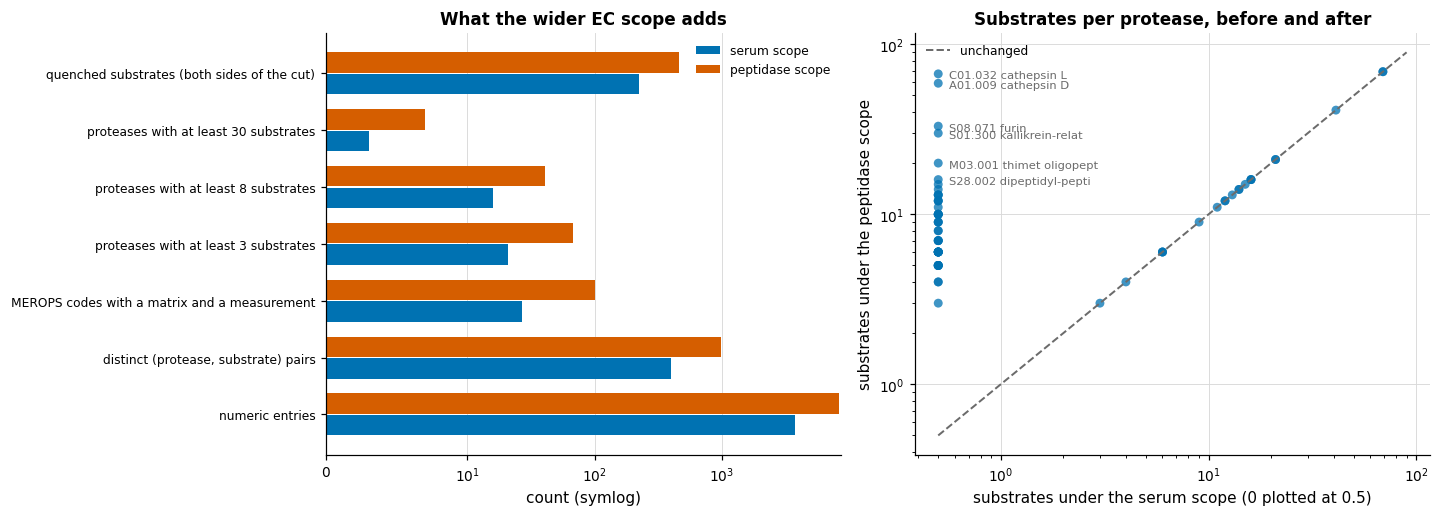

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))

ax = axes[0]
positions = np.arange(len(funnel))
ax.barh(positions - 0.19, funnel["serum_scope"], height=0.36, color=common.CATEGORICAL_COLORS[0], label="serum scope")
ax.barh(positions + 0.19, funnel["peptidase_scope"], height=0.36, color=common.CATEGORICAL_COLORS[1], label="peptidase scope")
ax.set_yticks(positions)
ax.set_yticklabels(funnel["quantity"], fontsize=8)
ax.set_xscale("symlog", linthresh=10)
ax.set_xlabel("count (symlog)")
ax.set_title("What the wider EC scope adds")
ax.legend(fontsize=8)
ax.grid(axis="y", visible=False)

ax = axes[1]
both = gained.query("peptidase_scope >= 3")
ax.scatter(
    both["serum_scope"].clip(lower=0.5),
    both["peptidase_scope"],
    s=34,
    color=common.CATEGORICAL_COLORS[0],
    alpha=0.75,
    edgecolor="none",
)
limit = both["peptidase_scope"].max() * 1.3
ax.plot([0.5, limit], [0.5, limit], color=common.NEUTRAL, linestyle="--", linewidth=1.3, label="unchanged")
for code, row in both.nlargest(6, "added").iterrows():
    ax.annotate(
        f"{code} {names.get(code, '')[:16]}",
        (max(row["serum_scope"], 0.5), row["peptidase_scope"]),
        textcoords="offset points",
        xytext=(7, -3),
        fontsize=7.5,
        color=common.NEUTRAL,
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("substrates under the serum scope (0 plotted at 0.5)")
ax.set_ylabel("substrates under the peptidase scope")
ax.set_title("Substrates per protease, before and after")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Provenance**

`assets/scripts/downloads/serum_proteolysis_calibration/map_ec_to_merops.py` scans BRENDA peptidase EC numbers, queries reviewed human UniProt entries and MEROPS cross-references, then writes `data/serum_proteolysis_calibration/manifests/peptidase_ec_to_merops.tsv`. `ingest_brenda.py` extracts BRENDA 2026.1 to `brenda_all_peptidases.parquet`, with unresolved mappings in `peptidase_ec_unresolved.json`; the coverage JSON reports 139 requested EC numbers and 8,366 retained parameter entries. Code cells 16–17 reduce numeric rows to distinct `(MEROPS code, substrate sequence)` pairs with a scoreable substrate window; `results/0_10_brenda_extension.csv` counts pairs by code in narrow and extended scope. A single EC measurement can be mapped to several codes, recorded by `shares_measurements_with_n_codes`; these rows are dependent. Inspect the mapping TSV and `usable_pairs` in code cell 16 for each exclusion. The code's window and mapping filters are not an independent validation of catalytic specificity.


## Integration table

One row per MEROPS code reachable under either scope, with the substrate counts
and whether the code is new. This is the coverage record for the wider source
and the input to `2_03_relation_extended.ipynb`.

In [12]:
integration = gained.reset_index().rename(columns={"index": "merops_code"})
integration["name"] = integration["merops_code"].map(names)
integration["merops_cleavages"] = integration["merops_code"].map(
    wide_pairs.groupby("merops_code")["merops_cleavages"].first()
)
integration["quenched_substrates"] = integration["merops_code"].map(
    wide_pairs.query("window_convention == 'quenched'").groupby("merops_code").size()
).fillna(0).astype(int)
integration["scope"] = np.where(
    integration["serum_scope"] > 0, "serum_and_peptidase", "peptidase_only"
)
integration["shares_measurements_with_n_codes"] = (
    integration["merops_code"].map(code_ambiguity).fillna(1).astype(int)
)

destination = common.save_result(integration, "0_10_brenda_extension.csv")
print(f"written: {destination.relative_to(common.ROOT)}")
print()
print(integration["scope"].value_counts().to_string())
integration.sort_values("peptidase_scope", ascending=False).head(15)

written: assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/0_10_brenda_extension.csv

scope
peptidase_only         74
serum_and_peptidase    27


,merops_code,serum_scope,peptidase_scope,added,name,merops_cleavages,quenched_substrates,scope,shares_measurements_with_n_codes
61,S01.160,69,69,0,kallikrein 1,31,58,serum_and_peptidase,2
62,S01.161,69,69,0,kallikrein-related peptidase 2,66,58,serum_and_peptidase,2
3,C01.032,0,67,67,cathepsin L,2956,64,peptidase_only,2
0,A01.009,0,59,59,cathepsin D,923,59,peptidase_only,1
56,S01.140,41,41,0,chymase ({Homo sapiens}-type),107,12,serum_and_peptidase,1
86,S08.071,0,33,33,furin,217,22,peptidase_only,1
83,S01.300,0,30,30,kallikrein-related peptidase 7,43,22,peptidase_only,1
55,S01.134,21,21,0,myeloblastin,55,8,serum_and_peptidase,1
32,M10.009,21,21,0,matrix metallopeptidase-12,312,21,serum_and_peptidase,1
30,M03.001,0,20,20,thimet oligopeptidase,124,20,peptidase_only,1
